In [57]:
#imports
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

Candidates:

'Cotrim_Figueiredo'
'Gouveia_Melo'
'Filipe'
'Marques_Mendes'
'Martins'
'Ventura'
'Pinto'
'Seguro'

In [58]:
# Select candidates 

person1 = 'Pinto'
person2 = 'Gouveia_Melo'

## Load data

In [59]:
# ── Visual ────────────────────────────────────────────────────────────────────
pklfiles_visual = []
for file in os.listdir('Project_Features'):
    if file.endswith('visual.pkl') and person1 in file and person2 in file:
        pklfiles_visual.append(file)

visual_dfs = []
for video in pklfiles_visual:
    print(f"Loading visual: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    visual_dfs.append(df)

df_visual = pd.concat(visual_dfs, ignore_index=True)
df_visual['video'] = df_visual['Frame'].str.extract(r'Frames/([^/]+)/')
df_visual['frame_number'] = df_visual['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)
df_visual = df_visual.sort_values(by=['video', 'frame_number']).reset_index(drop=True)

# ── Audio ─────────────────────────────────────────────────────────────────────
pklfiles_audio = []
for file in os.listdir('Project_Features'):
    if file.endswith('audio.pkl') and person1 in file and person2 in file:
        pklfiles_audio.append(file)

audio_dfs = []
for video in pklfiles_audio:
    print(f"Loading audio: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    df['video'] = video.replace('_audio.pkl', '')
    audio_dfs.append(df)

df_audio = pd.concat(audio_dfs, ignore_index=True)
df_audio = df_audio.sort_values(by=['video', 'time stamp']).reset_index(drop=True)

def parse_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

df_audio['speak_embeddings'] = df_audio['speak_embeddings'].apply(parse_embedding)

Loading visual: Pinto_vs_Gouveia_Melo_November_26_visual.pkl
Loading audio: Pinto_vs_Gouveia_Melo_November_26_audio.pkl


## Gap verification

In [60]:
# Check the time coverage of audio segments
df_audio['time_end'] = df_audio['time stamp'] + df_audio['duration']

# Look at gaps between consecutive segments
df_audio_sorted = df_audio.sort_values('time stamp').reset_index(drop=True)
df_audio_sorted['gap'] = df_audio_sorted['time stamp'] - df_audio_sorted['time_end'].shift(1)

print(df_audio_sorted['gap'].describe())
print(f"\nFrames with no covering audio segment (gaps > 0): {(df_audio_sorted['gap'] > 0).sum()}")

count    99.000000
mean      3.887202
std       6.499793
min      -4.085000
25%       0.236000
50%       1.316000
75%       5.340500
max      34.830000
Name: gap, dtype: float64

Frames with no covering audio segment (gaps > 0): 86


This means a significant number of frames will have no matching audio segment. So we have two options for how to handle unmatched frames:

Option A — Drop them. Only keep frames that fall inside an audio segment. Cleaner data but we lose information, especially during silences between turns.

Option B — Keep them with NaN. Keep all frames and just leave audio features as NaN for unmatched ones. More complete picture but needs careful handling in the correlation analysis.

## Time alignement

In [61]:
# ── Time alignment ────────────────────────────────────────────────────────────
# frame_number = second at which the frame was captured (1 fps)
# Each audio segment covers [time stamp, time stamp + duration)
# For each frame, find the audio segment active at that second (Option A: drop unmatched frames)

matched_rows = []

for _, frame_row in df_visual.iterrows():
    t = frame_row['frame_number']
    
    # Find audio segment where t falls inside [time stamp, time_end)
    match = df_audio[(df_audio['time stamp'] <= t) & (df_audio['time_end'] > t)]
    
    if len(match) == 1: # len = 0 -> frame in gap; len > 1 -> overlapping segments, both cases we drop the frame
        combined = {**frame_row.to_dict(), **match.iloc[0].to_dict()} # Merge the two rows into one dictionary
        matched_rows.append(combined)

df_merged = pd.DataFrame(matched_rows).reset_index(drop=True)

print(f"Visual frames total:        {len(df_visual)}")
print(f"Frames matched to audio:    {len(df_merged)}")
print(f"Frames dropped (no match):  {len(df_visual) - len(df_merged)}")

Visual frames total:        2114
Frames matched to audio:    1683
Frames dropped (no match):  431


## Emotion/Audio Analysis

### Maping people to audio

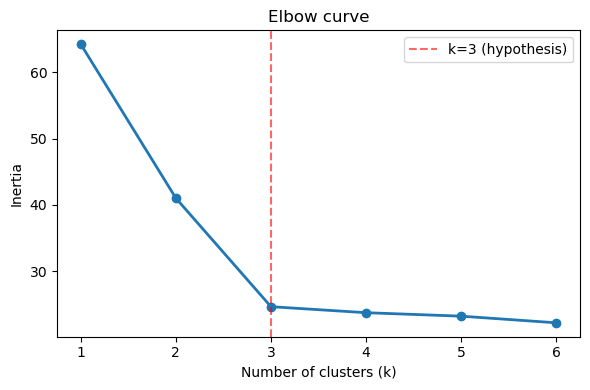

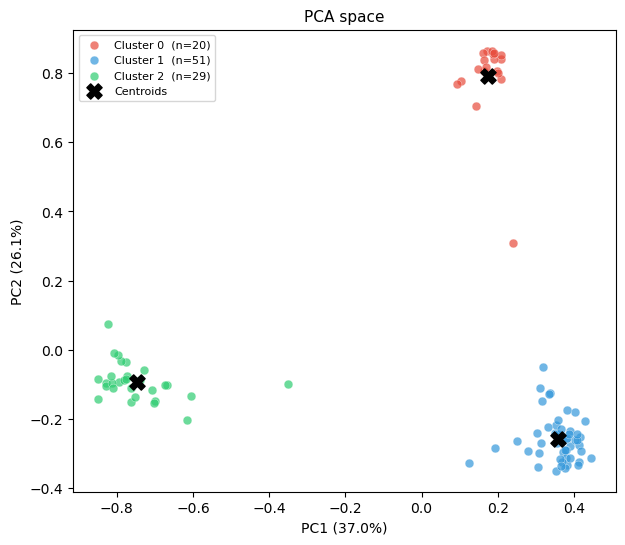

Silhouette Score for KMeans (k=3): 0.451


In [62]:
E = np.stack(df_audio['speak_embeddings'].values) 


pca = PCA(n_components=2, random_state=42) # Fit PCA on the original high-dimensional embeddings
E_2d = pca.fit_transform(E)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

#  ---------- Elbow method to find optimal k ----------
ks = range(1, 7)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E).inertia_ for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ks), inertias, marker='o', linewidth=2)
ax.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (hypothesis)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title(f'Elbow curve')
ax.legend()
plt.tight_layout()
plt.show()

colors = ['#e74c3c', '#3498db', '#2ecc71']

# ---------- KMeans clustering with k=3 ----------
k = 3 
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(E)

df_audio['cluster'] = labels # Add cluster labels to df_audio 

# Visualize clusters in PCA space
plt.figure(figsize=(7, 6))
for i in range(k):
    mask = labels == i
    plt.scatter(E_2d[mask, 0], E_2d[mask, 1], c=colors[i],
                   label=f'Cluster {i}  (n={mask.sum()})',
                   alpha=0.7, s=40, edgecolors='white', linewidth=0.3)
    centroids_2d = pca.transform(km.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            c='black', marker='X', s=120, zorder=5, label='Centroids')
plt.title('PCA space', fontsize=11)
plt.xlabel(f'PC1 ({var1:.1f}%)')
plt.ylabel(f'PC2 ({var2:.1f}%)')
plt.legend(fontsize=8)

plt.show()

# ---------- add the cluster labels to df_merged ----------
df_merged = df_merged.merge(
    df_audio[['time stamp', 'cluster']],
    on='time stamp',
    how='left'
)

# ---------- Silhouette score for KMeans ----------
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(E, labels)
print(f"Silhouette Score for KMeans (k=3): {sil_score:.3f}")

In [63]:
print(df_merged['cluster'].value_counts())
print('\n')
print(df_audio.groupby('cluster')['duration'].sum())
print(df_audio.groupby('cluster')['duration'].mean())

cluster
0    807
1    491
2    385
Name: count, dtype: int64


cluster
0    816.380
1    501.305
2    401.120
Name: duration, dtype: float64
cluster
0    40.819000
1     9.829510
2    13.831724
Name: duration, dtype: float64


Using only frames with exacly 1 face because thats the only way (that I know of) to be sure of who is talking

In [64]:
def count_faces(face_list):
    if isinstance(face_list, list):
        return sum(1 for face in face_list)
    
    return 0


df_merged['face_count'] = df_merged['Fer'].apply(count_faces)


# filter df_merged to have only frames with one face detected
df_one_face = df_merged[df_merged['face_count'] == 1]

In [65]:
print(f"Total frames in df_merged:        {len(df_merged)}")
print(f"Frames with exactly 1 face:       {len(df_one_face)}")
print(f"Cluster distribution in 1-face frames:")
print(df_one_face['cluster'].value_counts())

Total frames in df_merged:        1683
Frames with exactly 1 face:       1293
Cluster distribution in 1-face frames:
cluster
0    593
1    372
2    328
Name: count, dtype: int64


In [66]:
# Extract emotion probabilities from the single face in each frame
def extract_emotions(face_list):
    face = face_list[0]  # we know there is exactly 1 face
    probs = face['probabilities']  # dictionary with 8 emotion keys
    result = {'top_emotion': face['top_emotion']}
    for emotion, prob in probs.items():
        result[f'prob_{emotion}'] = prob
    return pd.Series(result)

emotion_cols = df_one_face['Fer'].apply(extract_emotions)
df_one_face = pd.concat([df_one_face, emotion_cols], axis=1)

print(df_one_face[['top_emotion'] + [c for c in df_one_face.columns if c.startswith('prob_')]].head())

  top_emotion  prob_Anger  prob_Contempt  prob_Disgust  prob_Fear  \
0     Disgust    0.150145       0.070313      0.502967   0.032408   
1     Disgust    0.189789       0.057136      0.550897   0.064059   
2    Contempt    0.115446       0.330056      0.177091   0.021499   
3     Disgust    0.254429       0.097104      0.325899   0.041801   
4    Surprise    0.244863       0.049218      0.099822   0.045682   

   prob_Happiness  prob_Neutral  prob_Sadness  prob_Surprise  
0        0.044682      0.092777      0.054919       0.051787  
1        0.068737      0.042696      0.010686       0.016001  
2        0.114353      0.160167      0.038351       0.043037  
3        0.052762      0.151468      0.024109       0.052429  
4        0.013425      0.137969      0.036851       0.372170  


### global correlation - emotion prob and voice features

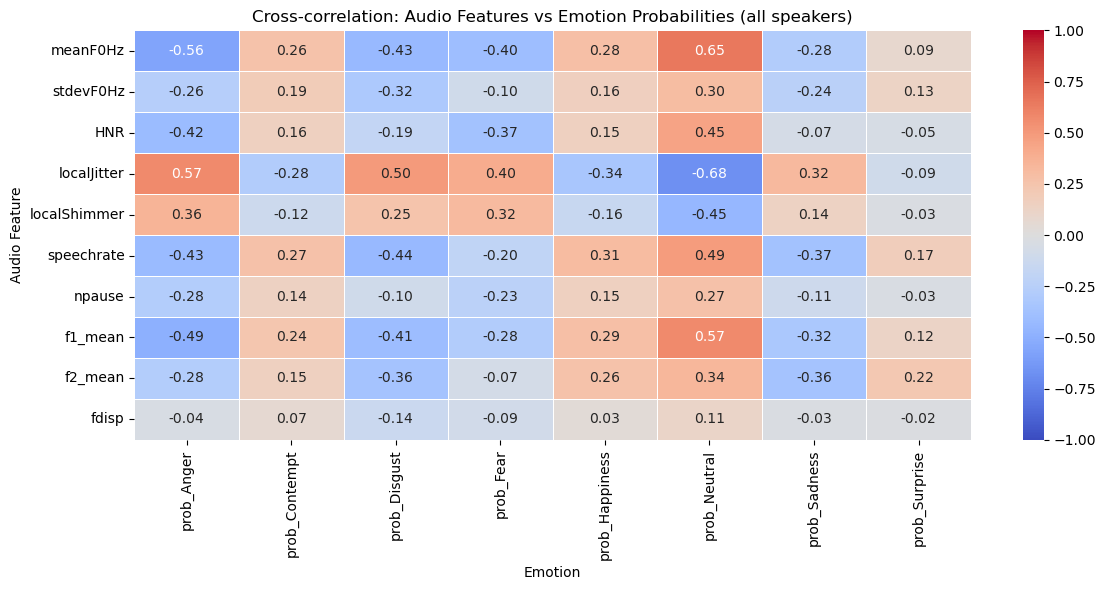

In [67]:
emotion_cols = [c for c in df_one_face.columns if c.startswith('prob_')]

NON_REDUNDANT = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
] # based on EDA from Dinis


# correlation matrix for the non-redundant features + emotion probabilities
features_to_corr = NON_REDUNDANT + emotion_cols
corr_matrix = df_one_face[features_to_corr].corr()

cross_corr = corr_matrix.loc[NON_REDUNDANT, emotion_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Cross-correlation: Audio Features vs Emotion Probabilities (all speakers)')
plt.xlabel('Emotion')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()


1. meanF0Hz (pitch) — strong negative correlation with Anger (-0.56) and strong positive with Neutral (0.65). Higher pitch → more neutral, lower pitch → more angry. Interesting!

2. localJitter — strongest correlations overall, positive with Anger (0.57) and negative with Neutral (-0.68). Jitter measures voice irregularity which makes sense for emotional speech

3. speechrate — negative with Anger (-0.43) and positive with Neutral (0.49). People speak slower when angry

4. fdisp — almost no correlation with anything, we could drop it

----

2. makes sense

3. I was expecting the opposite:

Debate-specific reason — in a formal political debate, "angry" speech might actually be more deliberate and slow — candidates may slow down and speak more carefully/forcefully when making a strong point, rather than speaking fast. Fast speech in debates might actually correspond to more relaxed, neutral moments.

Statistical reason — these are Pearson correlations which assume linear relationships. The real relationship might be more complex or driven by a confounding variable like speaker identity — one speaker might naturally speak slower AND happen to show more anger.


1. would expect the opposite:

This actually points to a bigger issue — these global correlations might be heavily confounded by speaker identity. Think about it:

Different speakers have naturally different baseline pitch — a female voice has inherently higher meanF0Hz than a male voice regardless of emotion
If one speaker happens to be more neutral overall AND has a higher pitch naturally, the correlation between high pitch and neutral would appear even if within each speaker the relationship is the opposite

### Per cluster analysis

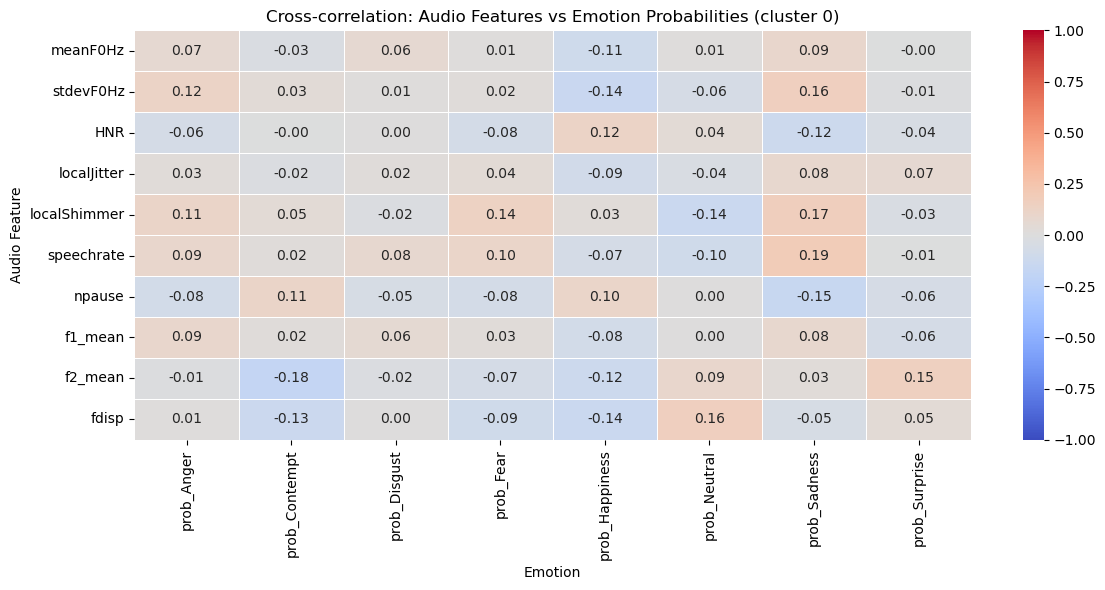

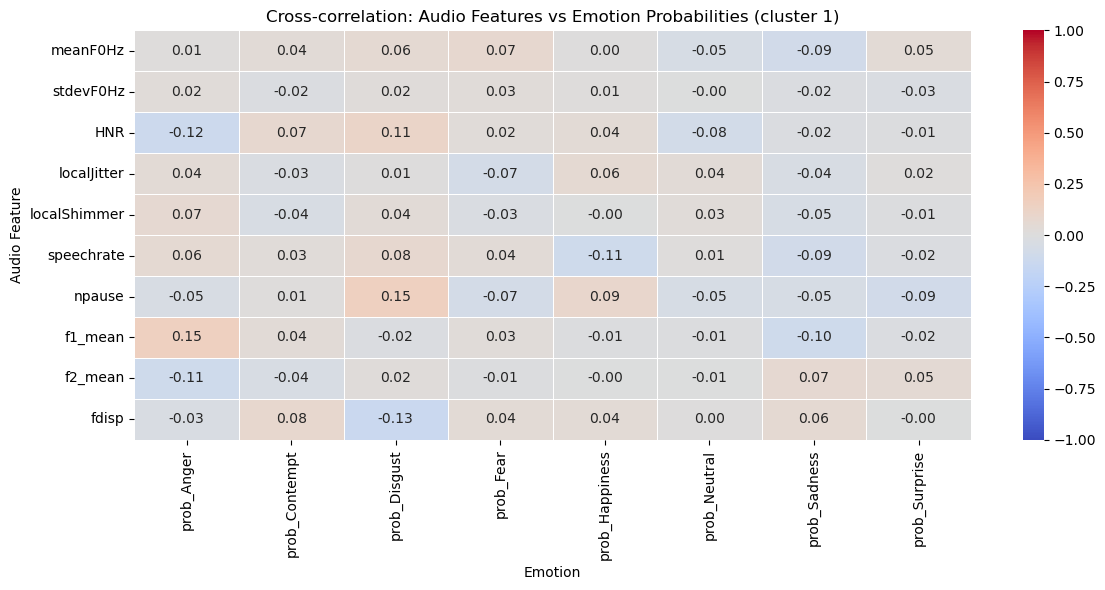

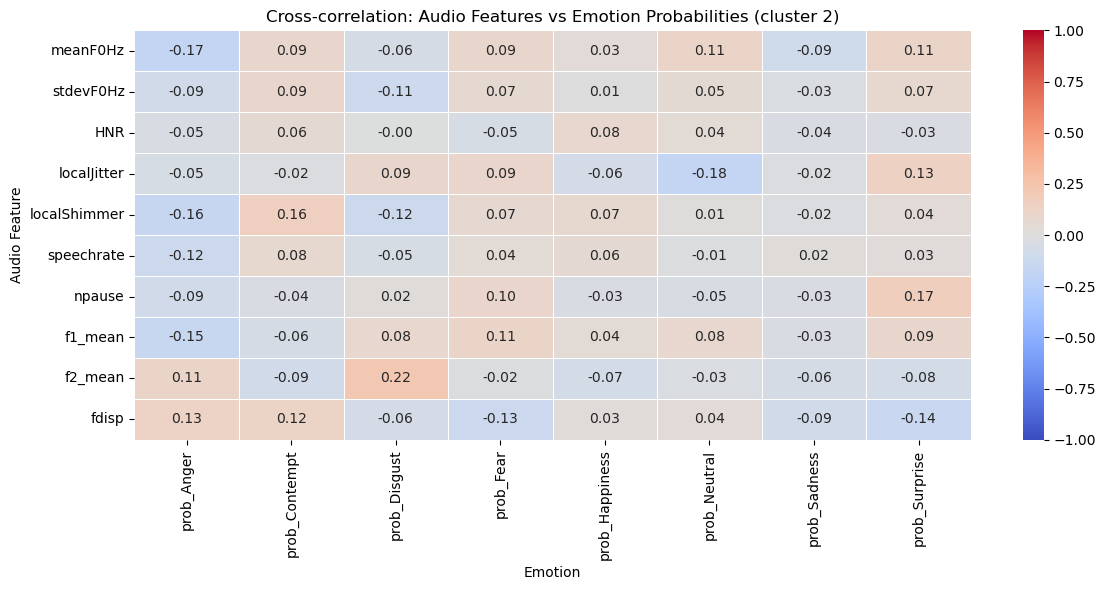

In [68]:
for cluster_id in sorted(df_one_face['cluster'].unique()):
    df_cluster = df_one_face[df_one_face['cluster'] == cluster_id]
    corr_matrix = df_cluster[features_to_corr].corr()
    cross_corr = corr_matrix.loc[NON_REDUNDANT, emotion_cols]

    plt.figure(figsize=(12, 6))
    sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f'Cross-correlation: Audio Features vs Emotion Probabilities (cluster {cluster_id})')
    plt.xlabel('Emotion')
    plt.ylabel('Audio Feature')
    plt.tight_layout()
    plt.show()
    

In [69]:
for cluster_id in sorted(df_one_face['cluster'].unique()):
    df_cluster = df_one_face[df_one_face['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} — top_emotion distribution:")
    print(df_cluster['top_emotion'].value_counts())


Cluster 0 — top_emotion distribution:
top_emotion
Neutral      382
Contempt      95
Surprise      60
Happiness     31
Anger         18
Sadness        5
Disgust        2
Name: count, dtype: int64

Cluster 1 — top_emotion distribution:
top_emotion
Anger        147
Sadness      103
Disgust       76
Contempt      20
Surprise      12
Neutral        9
Happiness      4
Fear           1
Name: count, dtype: int64

Cluster 2 — top_emotion distribution:
top_emotion
Anger        152
Surprise      64
Disgust       34
Contempt      29
Sadness       20
Happiness     14
Neutral       13
Fear           2
Name: count, dtype: int64


CONCLUSION: there is no meaningful within-speaker audio-emotion correlation in this debate?????

Simpson's Paradox: a statistical phenomenon where a trend or association observed in separate groups of data disappears or completely reverses when those groups are combined.